In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F
import random 

In [2]:
def fix_seeds(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [4]:
class RNN1(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_sleep_size, context_size, output_size=7, num_layers=1, modulation_strength=0):
        super(RNN1, self).__init__()

        self.context_fc = nn.Linear(hidden_sleep_size, context_size, bias=False)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, nonlinearity='relu', batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.modulation_strength = modulation_strength

    def set_modulation(self, val):
        self.modulation_strength = val
        
    def forward(self, x, hs, h=None):
        context = self.context_fc(hs)
        # print(hs, context, 'sjs')
        x = torch.cat(((1-self.modulation_strength)*x, self.modulation_strength*context), dim=2)
        # print(x)
        out, h = self.rnn(x, h)
        out = self.fc(out[:,-1,:])

        return out, h

In [5]:
class RNN2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(RNN2, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, nonlinearity='relu', batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

        self._init_weights_to_zero()

    def forward(self, x, h=None):
        out, h = self.rnn(x, h)
        out = self.fc(out[:,-1,:])

        return out, h
    
    def _init_weights_to_zero(self):
        # Zero out RNN weights and biases
        for name, param in self.rnn.named_parameters():
            nn.init.constant_(param, 0.0)

        # Zero out Linear layer weights and biases
        nn.init.constant_(self.fc.weight, 0.0)
        nn.init.constant_(self.fc.bias, 0.0)

In [6]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [19]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 40
hidden_sleep_size = 100
context_output_size = 10
num_layers_wake = 1
num_layers_sleep = 1
output_size = len(tokens)
input_size = len(tokens)*working_memory
lr = 1e-3
test_acc = []
c = []
cortical_strength = .5

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)#gen_seq(total_samples) #

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = RNN1(input_size+context_output_size, hidden_wake_size, hidden_sleep_size, context_size=context_output_size, output_size=output_size, num_layers=num_layers_wake)
network1.set_modulation(cortical_strength)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
hs = torch.zeros((1,1,hidden_sleep_size))
for X, y in train_loader:
    # context = torch.zeros((1,X.size(1),context_output_size))
    # X = torch.cat((X,context), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, h = network1(X,hs)
    else:
        predicted_y, h = network1(X, hs, h=mem)
    
    loss = criterion(predicted_y, y)
    
    
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem = h.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')


Iter : 1001, loss: 2.1122, accuracy: 0.2430
Iter : 2001, loss: 1.8873, accuracy: 0.2520
Iter : 3001, loss: 1.5366, accuracy: 0.3530
Iter : 4001, loss: 3.2633, accuracy: 0.5170
Iter : 5001, loss: 1.2353, accuracy: 0.5620
Iter : 6001, loss: 1.6654, accuracy: 0.6080
Iter : 7001, loss: 1.4896, accuracy: 0.6090
Iter : 8001, loss: 1.8232, accuracy: 0.5970
Iter : 9001, loss: 2.0130, accuracy: 0.6640
Iter : 10001, loss: 1.1553, accuracy: 0.6150
Iter : 11001, loss: 1.8665, accuracy: 0.6650
Iter : 12001, loss: 1.9108, accuracy: 0.6570
Iter : 13001, loss: 2.4029, accuracy: 0.6720
Iter : 14001, loss: 2.0270, accuracy: 0.6580
Iter : 15001, loss: 1.6845, accuracy: 0.6710
Iter : 16001, loss: 1.5995, accuracy: 0.6770
Iter : 17001, loss: 1.6776, accuracy: 0.6600
Iter : 18001, loss: 2.3601, accuracy: 0.6540
Iter : 19001, loss: 1.7748, accuracy: 0.6590
Iter : 20001, loss: 1.7786, accuracy: 0.6800
Iter : 21001, loss: 1.7556, accuracy: 0.6720
Iter : 22001, loss: 1.7952, accuracy: 0.6600
Iter : 23001, loss:

# Test randomness with noise injection

In [20]:
total_samples = 1000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
cortical_strength = .01
SWR = 0
counts = []
seq = ''

network1.set_modulation(cortical_strength)
hs = torch.randn((1,1,hidden_sleep_size))
network2 = RNN2(hidden_wake_size, hidden_sleep_size, hidden_wake_size, num_layers=num_layers_sleep)
optimizer = torch.optim.SGD(network2.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.MSELoss()

prev_h = torch.randn((1,1,hidden_wake_size))
mem = hs.clone()
for jj in range(total_samples):
    fix_seeds()
    with torch.no_grad():
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hs)
        else:
            hidden_state += SWR*torch.randn(hidden_state.size())
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hs, hidden_state)

        h_target = hidden_state.clone()

    ### train RNN2 ###
    optimizer.zero_grad()
    predicted_h, hs = network2(prev_h, mem)
    loss = criterion(predicted_h[0][0], h_target[0][0])
    
    
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem = hs.clone()
        X_hat_prob = torch.nn.functional.softmax(X_hat_, dim=1)
        fix_seeds(10)
        dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
        idx = dist_categ.sample()
        # idx = X_hat_prob.argmax()

        # noise = 10*torch.randn(context_output_size)
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        # X_hat[len(tokens):] = noise
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq = seq + tokens[idx]
        prev_h = hidden_state.clone()

        if jj%10000==0:
            print(loss)

        

tensor(0.2966, grad_fn=<MseLossBackward0>)


In [21]:
seq[:100]

'FEGCBAGDFEGDFEGCBAGDFEGCBAGDFEGCBGCBAGDFEGCBAGDFEGCBAGDFEGDFEGCBAGDFEGCBAGDFEGCBGCBAGDFEGCBAGDFEGCBA'

In [40]:
total_samples = 1000
idx = torch.randint(0, len(tokens), (1,)) [0]
X_hat = torch.zeros(len(tokens),dtype=torch.float32)
X_hat[idx] = 1.0
cortical_strength = .01
SWR = .65
counts = []
seq_ = ''

network1.set_modulation(cortical_strength)
hs = torch.randn((1,1,hidden_sleep_size))
network2 = RNN2(hidden_wake_size, hidden_sleep_size, hidden_wake_size, num_layers=num_layers_sleep)
optimizer = torch.optim.SGD(network2.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.MSELoss()

prev_h = torch.randn((1,1,hidden_wake_size))
mem = hs.clone()
for jj in range(total_samples):
    fix_seeds()
    with torch.no_grad():
        if jj == 0:
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hs)
        else:
            hidden_state += SWR*torch.randn(hidden_state.size())
            X_hat_, hidden_state = network1(X_hat.reshape(1,1,-1), hs, hidden_state)

        h_target = hidden_state.clone()

    ### train RNN2 ###
    optimizer.zero_grad()
    predicted_h, hs = network2(prev_h, mem)
    loss = criterion(predicted_h[0][0], h_target[0][0])
    
    
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem = hs.clone()
        X_hat_prob = torch.nn.functional.softmax(X_hat_, dim=1)
        fix_seeds(10)
        dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
        idx = dist_categ.sample()
        # idx = X_hat_prob.argmax()

        # noise = 10*torch.randn(context_output_size)
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        # X_hat[len(tokens):] = noise
        X_hat[idx] = 1.0
        X_hat = X_hat.reshape(1,1,-1)
        seq_ = seq_ + tokens[idx]
        prev_h = hidden_state.clone()

        if jj%10000==0:
            print(loss)

        

tensor(0.3757, grad_fn=<MseLossBackward0>)


In [41]:
seq[:100]

'FEGCBAGDFEGDFEGCBAGDFEGCBAGDFEGCBGCBAGDFEGCBAGDFEGCBAGDFEGDFEGCBAGDFEGCBAGDFEGCBGCBAGDFEGCBAGDFEGCBA'

In [42]:
seq_[:100]

'CBGCAGBACGAGBAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGCAGBAAGC'

# Do iterative sleep and wake stages

In [166]:
class brain:
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, context_output_size, num_layers_wake, num_layers_sleep, output_size=7, wake_lr=1e-3, sleep_lr=1e-3):
        self.wake_model = RNN1(input_size+context_output_size, hidden_wake_size, hidden_sleep_size, context_size=context_output_size, output_size=output_size, num_layers=num_layers_wake)
        self.wake_optimizer = torch.optim.SGD(self.wake_model.parameters(), lr=wake_lr, momentum=0.95)
        self.wake_criterion = torch.nn.CrossEntropyLoss()

        self.sleep_model = RNN2(hidden_wake_size, hidden_sleep_size, 2*hidden_wake_size, num_layers=num_layers_sleep)
        self.sleep_optimizer = torch.optim.SGD(self.sleep_model.parameters(), lr=sleep_lr, momentum=0.95)
        self.sleep_criterion = torch.nn.MSELoss()

        self.hidden_wake_size = hidden_wake_size
        self.hidden_sleep_size = hidden_sleep_size

    def wake(self, train_loader, cortical_strength=0.5):
        self.wake_model.set_modulation(cortical_strength)
        total = 0
        test_acc = []
        correct = np.zeros(1000,dtype=float)
        hs = torch.zeros((1,1,self.hidden_sleep_size))
        for X, y in train_loader:
            self.wake_optimizer.zero_grad()

            if total == 0:
                predicted_y, h = self.wake_model(X,hs)
            else:
                predicted_y, h = self.wake_model(X, hs, h=mem)
            
            loss = self.wake_criterion(predicted_y, y)
            
            
            loss.backward(retain_graph=True)
            self.wake_optimizer.step()

            with torch.no_grad():
                mem = h.clone()
                _, hs = self.sleep_model(h, hs)

                true_y = y.argmax(axis=1)
                estimated_y = predicted_y.argmax(axis=1)

                total += 1
                if true_y == estimated_y:
                        correct[total%1000] = 1
                else:
                    correct[total%1000] = 0

                test_acc.append(
                    np.sum(correct)/total if total<1000 else np.sum(correct)/1000
                )
                if total%1000 == 0:
                    print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
            
        return test_acc
    
    def sleep(self, sleep_duration=100000, cortical_strength=0.01, SWR=0.7):
        self.wake_model.set_modulation(cortical_strength)
        prev_h = torch.zeros((1,1,2*self.hidden_wake_size))
        hs = torch.zeros((1,1,self.hidden_sleep_size))
        mem = hs.clone()
        idx = torch.randint(0, len(tokens), (1,)) [0]
        X_hat = torch.zeros(len(tokens),dtype=torch.float32)
        X_hat[idx] = 1.0
        for jj in range(sleep_duration):
            with torch.no_grad():
                if jj == 0:
                    X_hat_, hidden_state = self.wake_model(X_hat.reshape(1,1,-1), hs)
                else:
                    hidden_state += SWR*torch.randn(hidden_state.size())
                    X_hat_, hidden_state = self.wake_model(X_hat.reshape(1,1,-1), hs, hidden_state)

                h_current = hidden_state.clone()

            ### train sleep model ###
            self.sleep_optimizer.zero_grad()
            predicted_h, hs = self.sleep_model(h_current, mem)
            # print(predicted_h[0], h_target[0])
            loss = self.sleep_criterion(predicted_h[0], prev_h[0][0])
            
            
            loss.backward(retain_graph=True)
            optimizer.step()

            with torch.no_grad():
                mem = hs.clone()
                X_hat_prob = torch.nn.functional.softmax(X_hat_, dim=1)
                dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
                idx = dist_categ.sample()
                
                X_hat = torch.zeros(len(tokens),dtype=torch.float32)
                X_hat[idx] = 1.0
                X_hat = X_hat.reshape(1,1,-1)
                prev_h[0][0][hidden_wake_size:] = prev_h[0][0][:hidden_wake_size]
                prev_h[0][0][:hidden_wake_size] = hidden_state.clone()

                if jj%10000==0:
                    print('Sleep loss iteration ',jj,': ',loss)

In [168]:
# total_samples = 200000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 40
hidden_sleep_size = 100
context_output_size = 10
num_layers_wake = 1
num_layers_sleep = 1
output_size = len(tokens)
input_size = len(tokens)*working_memory
lr = 1e-3
test_acc = []
wake_sleep_cycle = 5


model = brain(input_size, hidden_wake_size, hidden_sleep_size, context_output_size, num_layers_wake, num_layers_sleep, output_size=output_size, wake_lr=lr, sleep_lr=lr)

for cycle in range(wake_sleep_cycle):
    if cycle == 0:
        total_samples = 40000
    else:
        total_samples = 100000

    data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

    data_set = Dataset_converter(data, working_memory, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    model.wake(train_loader)
    model.sleep()

Iter : 1001, loss: 2.0842, accuracy: 0.2490
Iter : 2001, loss: 1.9386, accuracy: 0.2500
Iter : 3001, loss: 1.5202, accuracy: 0.3460
Iter : 4001, loss: 3.1741, accuracy: 0.5130
Iter : 5001, loss: 1.5084, accuracy: 0.5540
Iter : 6001, loss: 2.4464, accuracy: 0.5640
Iter : 7001, loss: 1.3431, accuracy: 0.6030
Iter : 8001, loss: 1.9884, accuracy: 0.5910
Iter : 9001, loss: 2.3734, accuracy: 0.6350
Iter : 10001, loss: 1.7058, accuracy: 0.6690
Iter : 11001, loss: 2.0735, accuracy: 0.6690
Iter : 12001, loss: 2.3531, accuracy: 0.6610
Iter : 13001, loss: 1.9275, accuracy: 0.6500
Iter : 14001, loss: 1.6529, accuracy: 0.6630
Iter : 15001, loss: 1.6381, accuracy: 0.6650
Iter : 16001, loss: 1.8326, accuracy: 0.6610
Iter : 17001, loss: 1.6484, accuracy: 0.6710
Iter : 18001, loss: 1.7923, accuracy: 0.6670
Iter : 19001, loss: 1.7567, accuracy: 0.6620
Iter : 20001, loss: 1.7519, accuracy: 0.6770
Iter : 21001, loss: 1.7954, accuracy: 0.6710
Iter : 22001, loss: 1.7308, accuracy: 0.6600
Iter : 23001, loss:

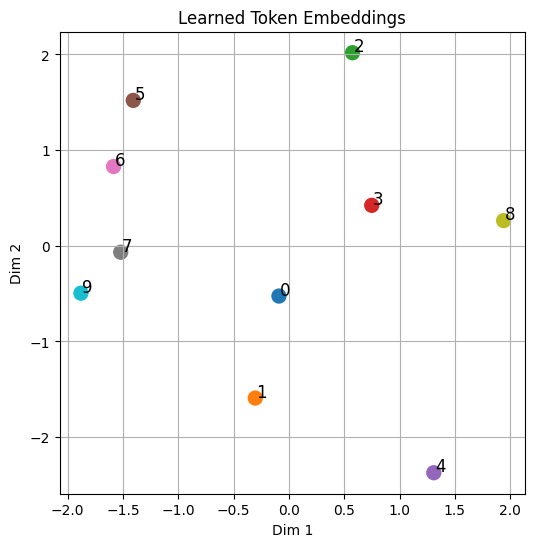

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Config
num_tokens = 10
embedding_dim = 2
hidden_dim = 16
sequence_length = 1000

# Generate synthetic data
sequence = torch.tensor([(i % num_tokens) for i in range(sequence_length)])

# Model
class TokenPredictor(nn.Module):
    def __init__(self, num_tokens, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_tokens, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_tokens)

    def forward(self, x, h=None):
        x = self.embedding(x)
        out, h = self.rnn(x, h)
        out = self.fc(out)
        return out, h

model = TokenPredictor(num_tokens, embedding_dim, hidden_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# Training
batch_size = 32
for epoch in range(100):
    for i in range(0, sequence_length - batch_size - 1, batch_size):
        x = sequence[i:i+batch_size].unsqueeze(0)
        y = sequence[i+1:i+batch_size+1].unsqueeze(0)

        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits.squeeze(0), y.squeeze(0))
        loss.backward()
        optimizer.step()

# Visualize embeddings
embeddings = model.embedding.weight.detach().numpy()
plt.figure(figsize=(6,6))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c=np.arange(num_tokens), cmap='tab10', s=100)
for i in range(num_tokens):
    plt.text(embeddings[i, 0]+0.01, embeddings[i, 1]+0.01, str(i), fontsize=12)
plt.title("Learned Token Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(True)
plt.show()
